# Load Data

In [2]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from scipy.stats import linregress

sns.set_style("whitegrid")

Load NAV Data

In [3]:
nav = pd.read_csv(
    "../data/raw/02_nav_history.csv"
)

nav["date"] = pd.to_datetime(
    nav["date"]
)

nav = nav.sort_values(
    ["amfi_code", "date"]
)

nav.head()

,amfi_code,date,nav
5750,100016,2022-01-03,520.4608
5751,100016,2022-01-04,515.0971
5752,100016,2022-01-05,521.7239
5753,100016,2022-01-06,515.7880
5754,100016,2022-01-07,515.1639


Task 1: Daily Returns


In [4]:
nav["daily_return"] = (
    nav.groupby("amfi_code")["nav"]
       .pct_change()
)

nav.head()

,amfi_code,date,nav,daily_return
5750,100016,2022-01-03,520.4608,NaN
5751,100016,2022-01-04,515.0971,-0.010306
5752,100016,2022-01-05,521.7239,0.012865
5753,100016,2022-01-06,515.7880,-0.011377
5754,100016,2022-01-07,515.1639,-0.001210


Check Distribution

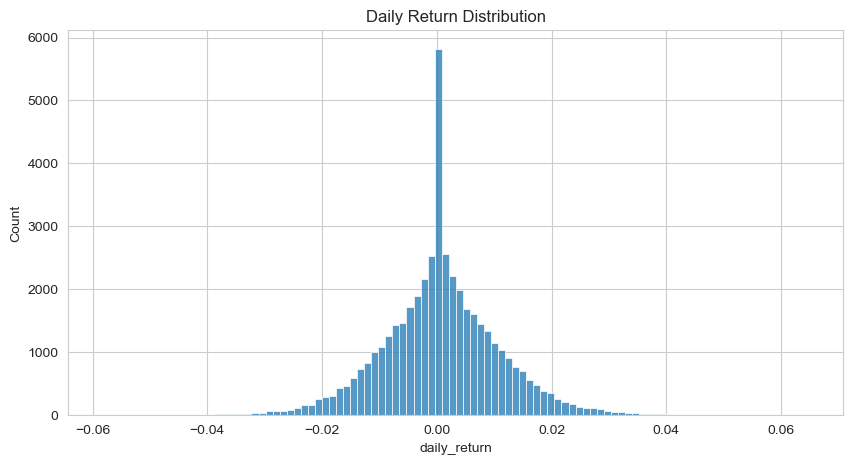

In [5]:
plt.figure(figsize=(10,5))

sns.histplot(
    nav["daily_return"].dropna(),
    bins=100
)

plt.title(
    "Daily Return Distribution"
)

plt.show()

 Summary statistics of daily returns

In [6]:

nav["daily_return"].describe()

count    45960.000000
mean         0.000631
std          0.010290
min         -0.058102
25%         -0.005042
50%          0.000340
75%          0.006324
max          0.064713
Name: daily_return, dtype: float64

Save Dataset

In [7]:
nav.to_csv(
    "../data/processed/nav_returns.csv",
    index=False
)

Task 2: CAGR

In [8]:
cagr_list = []

for fund in nav["amfi_code"].unique():

    temp = nav[
        nav["amfi_code"] == fund
    ].sort_values("date")

    start_nav = temp["nav"].iloc[0]

    end_nav = temp["nav"].iloc[-1]

    years = (
        temp["date"].max()
        -
        temp["date"].min()
    ).days / 365

    cagr = (
        (end_nav/start_nav)
        ** (1/years)
        - 1
    )

    cagr_list.append(
        [fund, cagr]
    )

cagr_df = pd.DataFrame(
    cagr_list,
    columns=[
        "amfi_code",
        "cagr"
    ]
)



In [9]:
cagr_df.head()

,amfi_code,cagr
0,100016,0.026352
1,100025,0.044551
2,100033,0.300997
3,101206,0.235205
4,101207,0.079331


Task 3: Sharpe Ratio

In [10]:
risk_free_rate = 0.065

In [11]:
sharpe_list = []

for fund in nav["amfi_code"].unique():

    temp = nav[
        nav["amfi_code"] == fund
    ]

    returns = temp["daily_return"].dropna()

    annual_return = (
        returns.mean() * 252
    )

    annual_volatility = (
        returns.std() * np.sqrt(252)
    )

    sharpe = (
        annual_return - risk_free_rate
    ) / annual_volatility

    sharpe_list.append(
        [fund, sharpe]
    )

sharpe_df = pd.DataFrame(
    sharpe_list,
    columns=[
        "amfi_code",
        "sharpe_ratio"
    ]
)

sharpe_df = sharpe_df.sort_values(
    "sharpe_ratio",
    ascending=False
)



In [12]:
sharpe_df.head()

,amfi_code,sharpe_ratio
34,148567,1.448291
30,120843,1.306744
36,148569,1.234930
19,119551,1.208267
25,120505,1.180101


Task 4: Sortino Ratio

In [14]:
sortino_list = []

for fund in nav["amfi_code"].unique():

    temp = nav[
        nav["amfi_code"] == fund
    ]

    returns = temp["daily_return"].dropna()

    downside = returns[
        returns < 0
    ]

    downside_std = (
        downside.std()
        * np.sqrt(252)
    )

    annual_return = (
        returns.mean()
        * 252
    )

    sortino = (
        annual_return
        - risk_free_rate
    ) / downside_std

    sortino_list.append(
        [fund, sortino]
    )

sortino_df = pd.DataFrame(
    sortino_list,
    columns=[
        "amfi_code",
        "sortino_ratio"
    ]
)



In [15]:
sortino_df.head()

,amfi_code,sortino_ratio
0,100016,-0.351047
1,100025,-0.941821
2,100033,1.829134
3,101206,1.799563
4,101207,0.276644


Task 5: Alpha & Beta

In [17]:
import pandas as pd
import numpy as np

from scipy.stats import linregress

import matplotlib.pyplot as plt
import seaborn as sns

In [20]:
benchmark = pd.read_csv("../data/raw/10_benchmark_indices.csv")

print(benchmark.columns)

Index(['date', 'index_name', 'close_value'], dtype='object')


In [21]:
benchmark.head()

,date,index_name,close_value
0,2022-01-03,NIFTY50,17492.79
1,2022-01-04,NIFTY50,17689.64
2,2022-01-05,NIFTY50,17835.05
3,2022-01-06,NIFTY50,17878.51
4,2022-01-07,NIFTY50,17759.15


In [22]:
benchmark.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8050 entries, 0 to 8049
Data columns (total 3 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   date         8050 non-null   object 
 1   index_name   8050 non-null   object 
 2   close_value  8050 non-null   float64
dtypes: float64(1), object(2)
memory usage: 188.8+ KB


In [24]:
benchmark["index_name"].unique()

array(['NIFTY50', 'CRISIL_LIQUID', 'NIFTY_MIDCAP150', 'CRISIL_GILT',
       'NIFTY100', 'NIFTY500', 'BSE_SMALLCAP'], dtype=object)

In [45]:
benchmark["date"] = pd.to_datetime(
    benchmark["date"]
)

benchmark = benchmark.sort_values(
    ["index_name", "date"]
)

benchmark["benchmark_return"] = (
    benchmark.groupby("index_name")[
        "close_value"
    ].pct_change()
)
benchmark.head()

,date,index_name,close_value,benchmark_return
3450,2022-01-03,BSE_SMALLCAP,26554.60,NaN
3451,2022-01-04,BSE_SMALLCAP,27079.92,0.019783
3452,2022-01-05,BSE_SMALLCAP,27313.35,0.008620
3453,2022-01-06,BSE_SMALLCAP,27377.05,0.002332
3454,2022-01-07,BSE_SMALLCAP,26316.86,-0.038726


Alpha & Beta Calculation

In [28]:
alpha_beta_list = []

nifty100 = benchmark[
    benchmark["index_name"] == "NIFTY100"
][["date", "benchmark_return"]]

for fund in nav["amfi_code"].unique():

    fund_df = nav[
        nav["amfi_code"] == fund
    ][["date", "daily_return"]]

    merged = pd.merge(
        fund_df,
        nifty100,
        on="date",
        how="inner"
    )

    merged = merged.dropna()

    if len(merged) > 50:

        beta, intercept, r, p, std = (
            linregress(
                merged["benchmark_return"],
                merged["daily_return"]
            )
        )

        alpha = intercept * 252

        alpha_beta_list.append(
            [fund, alpha, beta]
        )

alpha_beta_df = pd.DataFrame(
    alpha_beta_list,
    columns=[
        "amfi_code",
        "alpha",
        "beta"
    ]
)



In [29]:
alpha_beta_df.head()

,amfi_code,alpha,beta
0,100016,0.037476,-0.058268
1,100025,0.042818,0.001158
2,100033,0.271954,0.005104
3,101206,0.213998,0.021086
4,101207,0.108971,-0.065289


Save Deliverable

In [32]:
alpha_beta_df.to_csv(
    "../data/processed/alpha_beta.csv",
    index=False
)

Task 6: Maximum Drawdown

In [34]:
mdd_list = []

for fund in nav["amfi_code"].unique():

    temp = nav[
        nav["amfi_code"] == fund
    ].copy()

    temp["running_max"] = (
        temp["nav"].cummax()
    )

    temp["drawdown"] = (
        temp["nav"]
        /
        temp["running_max"]
        - 1
    )

    max_dd = temp[
        "drawdown"
    ].min()

    mdd_list.append(
        [fund, max_dd]
    )

mdd_df = pd.DataFrame(
    mdd_list,
    columns=[
        "amfi_code",
        "max_drawdown"
    ]
)


In [35]:
mdd_df.head()

,amfi_code,max_drawdown
0,100016,-0.247344
1,100025,-0.043083
2,100033,-0.162172
3,101206,-0.112916
4,101207,-0.354469


Task 7: Fund Scorecard (0–100)

In [36]:
scorecard = (
    cagr_df
    .merge(sharpe_df,on="amfi_code")
    .merge(alpha_beta_df,on="amfi_code")
    .merge(mdd_df,on="amfi_code")
)

scorecard.head()

,amfi_code,cagr,sharpe_ratio,alpha,beta,max_drawdown
0,100016,0.026352,-0.201517,0.037476,-0.058268,-0.247344
1,100025,0.044551,-0.567095,0.042818,0.001158,-0.043083
2,100033,0.300997,1.093699,0.271954,0.005104,-0.162172
3,101206,0.235205,1.027213,0.213998,0.021086,-0.112916
4,101207,0.079331,0.162661,0.108971,-0.065289,-0.354469


Create Rankings

In [37]:
scorecard["return_rank"] = (
    scorecard["cagr"]
    .rank(pct=True)
)

scorecard["sharpe_rank"] = (
    scorecard["sharpe_ratio"]
    .rank(pct=True)
)

scorecard["alpha_rank"] = (
    scorecard["alpha"]
    .rank(pct=True)
)

scorecard["mdd_rank"] = (
    (-scorecard["max_drawdown"])
    .rank(pct=True)
)

Fund Score Formula

In [38]:
scorecard["fund_score"] = (

      30 * scorecard["return_rank"]

    + 25 * scorecard["sharpe_rank"]

    + 20 * scorecard["alpha_rank"]

    + 25 * scorecard["mdd_rank"]

)

scorecard = scorecard.sort_values(
    "fund_score",
    ascending=False
)

scorecard.head()

,amfi_code,cagr,sharpe_ratio,alpha,beta,max_drawdown,return_rank,sharpe_rank,alpha_rank,mdd_rank,fund_score
39,149324,0.322621,0.949796,0.300579,0.011455,-0.311719,0.950,0.700,0.975,0.925,88.625
21,119598,0.323981,0.945308,0.303370,-0.023196,-0.287060,0.975,0.675,1.000,0.900,88.625
25,120505,0.328016,1.180101,0.292636,0.000549,-0.181885,1.000,0.900,0.950,0.625,87.125
36,148569,0.319245,1.234930,0.282704,0.018134,-0.163967,0.925,0.950,0.925,0.525,83.125
38,149323,0.295581,1.132122,0.265986,-0.002523,-0.172481,0.825,0.875,0.825,0.550,76.875


In [44]:
scorecard.to_csv(
    "../data/processed/fund_scorecard.csv",
    index=False
)

Benchmark Comparison Chart

In [40]:
top5 = (
    scorecard
    .head(5)["amfi_code"]
    .tolist()
)

Create chart

In [48]:
import plotly.express as px

top_nav = nav[
    nav["amfi_code"].isin(top5)
]

fig = px.line(
    top_nav,
    x="date",
    y="nav",
    color="amfi_code",
    title="Top 5 Funds NAV Comparison"
)

fig.show()

Save

In [43]:
fig.write_html(
    "../data/processed/benchmark_comparison.html"
)

In [47]:
scorecard.head()

,amfi_code,cagr,sharpe_ratio,alpha,beta,max_drawdown,return_rank,sharpe_rank,alpha_rank,mdd_rank,fund_score
39,149324,0.322621,0.949796,0.300579,0.011455,-0.311719,0.950,0.700,0.975,0.925,88.625
21,119598,0.323981,0.945308,0.303370,-0.023196,-0.287060,0.975,0.675,1.000,0.900,88.625
25,120505,0.328016,1.180101,0.292636,0.000549,-0.181885,1.000,0.900,0.950,0.625,87.125
36,148569,0.319245,1.234930,0.282704,0.018134,-0.163967,0.925,0.950,0.925,0.525,83.125
38,149323,0.295581,1.132122,0.265986,-0.002523,-0.172481,0.825,0.875,0.825,0.550,76.875
